In [ ]:
# NNSE (Nested Neutral Set Estimator) for Tyson Model
# Implements a mutation-based search through parameter space

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.decomposition import PCA
import copy

# ============================================================================
# === CONFIGURATION VARIABLES ===
# ============================================================================

# Simulation settings
N_STEPS = 10000  # Number of mutation steps to run
SIGMA = 0.01  # Standard deviation for Gaussian mutations in normalized space
N_BINS = 500  # Number of bins for binning squared differences
MAX_VALUE = 2.0  # Maximum log value for bin thresholds (logspace goes from 0 to this)
T_START = 0.0  # Simulation start time
T_END = 50.0  # Simulation end time
N_TIME_POINTS = 501  # Number of time points

# Define bin thresholds using logspace (equally spaced in log space)
# Creates N_BINS+1 thresholds for N_BINS bins: [10^0, 10^(1/N_BINS), ..., 10^MAX_LOG_VALUE]
bin_thresholds = np.linspace(0, MAX_VALUE, N_BINS + 1)

# ============================================================================
# === BASE PARAMETERS (p0) ===
# ============================================================================

p0 = {
    "k1_aa_over_CT": 0.015,
    "k2": 0.0,
    "k3_CT": 200.0,
    "k4": 180.0,
    "k4prime": 0.018,
    "k5_minusP": 0.0,
    "k6": 1.0,
    "k7": 0.6,
    "k8_minusP": 100.0,
    "k9": 50.0,
    "CT": 1.0
}

# Parameters to vary
param_names = [
    "k1_aa_over_CT",
    "k3_CT",
    "k4",
    "k4prime",
    "k6",
    "k7"
]

p0_vec = np.array([p0[name] for name in param_names])
n_params = len(param_names)

print(f"NNSE Configuration:")
print(f"  Parameters to vary: {param_names}")
print(f"  Number of parameters: {n_params}")
print(f"  Number of steps: {N_STEPS}")
print(f"  Mutation sigma: {SIGMA}")
print(f"  Number of bins: {N_BINS}")
print(f"  Max value for bins: {MAX_VALUE}")
print(f"  Bin thresholds range: [{bin_thresholds[0]:.4e}, {bin_thresholds[-1]:.4e}]")
print(f"  Time range: [{T_START}, {T_END}] with {N_TIME_POINTS} points")


NNSE Configuration:
  Parameters to vary: ['k1_aa_over_CT', 'k3_CT', 'k4', 'k4prime', 'k6', 'k7']
  Number of parameters: 6
  Number of steps: 10000
  Mutation sigma: 0.01
  Number of bins: 50
  Max value for bins: 2.0
  Bin thresholds range: [0.0000e+00, 2.0000e+00]
  Time range: [0.0, 50.0] with 501 points


In [70]:
# ============================================================================
# === TYSON MODEL DEFINITION ===
# ============================================================================

CT = p0["CT"]

def F_M(M, p):
    """Helper function for M-dependent rate"""
    return p["k4prime"] + p["k4"] * (M / p["CT"])**2

def f_rhs(t, x, p):
    """Right-hand side of the ODE system"""
    # x = [C2, CP, pM, M, Y, YP]
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    k1 = p["k1_aa_over_CT"] * p['CT']
    dC2 = p["k6"] * M - p["k8_minusP"] * C2 + p["k9"] * CP
    dCP = -k3 * CP * Y + p["k8_minusP"] * C2 - p["k9"] * CP
    dpM = k3 * CP * Y - pM * F_M(M, p) + p["k5_minusP"] * M
    dM  = pM * F_M(M, p) - p["k5_minusP"] * M - p["k6"] * M
    dY  = k1 - p["k2"] * Y - k3 * CP * Y
    dYP = p["k6"] * M - p["k7"] * YP
    return np.array([dC2, dCP, dpM, dM, dY, dYP])

def simulate_at_params(p_local, t_eval):
    """Simulate the ODE system with given parameters"""
    y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
    sol = solve_ivp(lambda tt, xx: f_rhs(tt, xx, p_local), 
                    (t_eval[0], t_eval[-1]), y0,
                    method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Integrator failed: " + sol.message)
    return sol.t, sol.y

def compute_obs(X):
    """Compute observables: YT/CT and M/CT"""
    if X.ndim == 1:
        C2, CP, pM, M, Y, YP = X
        YT = Y + YP + pM + M
        return YT / CT, M / CT
    else:
        C2, CP, pM, M, Y, YP = X
        YT = Y + YP + pM + M
        return YT / CT, M / CT

print("✓ Model functions defined")


✓ Model functions defined


Running reference simulation with p0...
✓ Reference simulation complete
  Time points: 501
  YT/CT range: [0.0906, 0.3591]
  M/CT range: [0.0016, 0.2128]


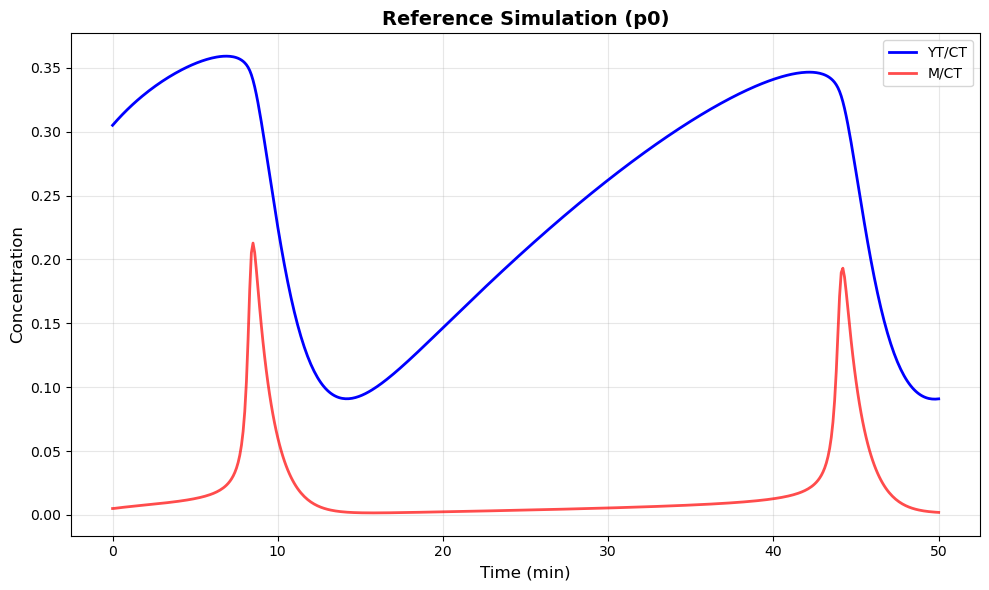

In [71]:
# ============================================================================
# === REFERENCE SIMULATION (p0) ===
# ============================================================================

print("Running reference simulation with p0...")
t_eval = np.linspace(T_START, T_END, N_TIME_POINTS)
t0, y0 = simulate_at_params(p0, t_eval)
YT0, M0 = compute_obs(y0)

print(f"✓ Reference simulation complete")
print(f"  Time points: {len(t0)}")
print(f"  YT/CT range: [{np.min(YT0):.4f}, {np.max(YT0):.4f}]")
print(f"  M/CT range: [{np.min(M0):.4f}, {np.max(M0):.4f}]")

# Plot reference trajectory
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t0, YT0, 'b-', lw=2, label='YT/CT')
ax.plot(t0, M0, 'r-', lw=2, label='M/CT', alpha=0.7)
ax.set_xlabel('Time (min)', fontsize=12)
ax.set_ylabel('Concentration', fontsize=12)
ax.set_title('Reference Simulation (p0)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [72]:
# ============================================================================
# === SIM FUNCTION ===
# ============================================================================

def sim(P_vec):
    """
    Simulate with parameter vector P and compute squared difference with p0.
    
    Args:
        P_vec: numpy array of parameter values (length n_params)
    
    Returns:
        P_vec: parameter vector (unchanged)
        bin_value: binned squared difference (0 to N_BINS-1)
        squared_diff: non-binned squared difference (for tracking)
    """
    # Convert parameter vector to dictionary
    p_local = copy.deepcopy(p0)
    for i, name in enumerate(param_names):
        p_local[name] = P_vec[i]
    
    # Run simulation
    try:
        t, y = simulate_at_params(p_local, t_eval)
        YT, M = compute_obs(y)
        
        # Interpolate reference to match time points
        YT0_interp = np.interp(t, t0, YT0)
        M0_interp = np.interp(t, t0, M0)
        
        # Compute squared differences
        diff_YT_sq = (YT - YT0_interp)**2
        diff_M_sq = (M - M0_interp)**2
        
        # Integrate squared differences
        integral_YT_sq = np.trapz(diff_YT_sq, t)
        integral_M_sq = np.trapz(diff_M_sq, t)
        squared_diff = integral_YT_sq + integral_M_sq
        
        # Bin the squared difference using predefined logspace thresholds (round up to nearest bin)
        if squared_diff > 0:
            # Find which bin the squared_diff belongs to (rounding up)
            bin_value = np.searchsorted(bin_thresholds, squared_diff, side='right')
            bin_value = min(bin_value, N_BINS - 1)  # Cap at max bin
        else:
            bin_value = 0
        
        return P_vec, bin_value, squared_diff
        
    except Exception as e:
        # If simulation fails, return high bin value
        print(f"Warning: Simulation failed: {e}")
        return P_vec, N_BINS - 1, np.inf

print("✓ Sim function defined")


✓ Sim function defined


In [73]:
# ============================================================================
# === MUTATE FUNCTION ===
# ============================================================================

def mutate(P_vec, binP):
    """
    Mutate parameter vector P and accept if bin value improves or stays same.
    
    Args:
        P_vec: current parameter vector
        binP: current bin value
    
    Returns:
        P_new: new parameter vector (mutated or original)
        binP_new: new bin value
        squared_diff_mutated: squared difference for the MUTATED parameter (for tracking)
    """
    # Normalize parameters: u_i = p_i / (2 * p0_i) so each lies in [0,1]
    u_vec = P_vec / (2.0 * p0_vec)
    
    # Apply Gaussian mutation in u-space
    u_mutated = u_vec + np.random.normal(0, SIGMA, size=n_params)
    
    # Wrap around boundaries [0, 1] with periodic boundary conditions
    # If u > 1: wrap to u - 1 (since 2*pi_0 + x maps to x)
    # If u < 0: wrap to 1 + u (since 0 - x maps to 2*pi_0 - x)
    u_mutated = u_mutated % 1.0  # This handles both cases with modulo
    
    # Map back to parameter space: p_i = 2 * p0_i * u_i
    P_mutated = 2.0 * p0_vec * u_mutated
    
    # Evaluate mutated parameter
    _, binP_mutated, squared_diff_mutated = sim(P_mutated)
    
    # Accept if bin value is <= current bin value (neutral or better)
    if binP_mutated <= binP:
        return P_mutated, binP_mutated, squared_diff_mutated
    else:
        return P_vec, binP, squared_diff_mutated  # Return mutated squared_diff for tracking

print("✓ Mutate function defined")


✓ Mutate function defined


In [ ]:
# ============================================================================
# === MAIN SIMULATION LOOP ===
# ============================================================================

print(f"Starting NNSE simulation for {N_STEPS} steps...")
print(f"Base parameter (p0): {p0_vec}")

# Initialize: start at a random point in the cube [0, 2*p0_i] for each parameter
# Generate random point in normalized u-space [0, 1]
u_random = np.random.uniform(0, 1, size=n_params)
# Map to parameter space: p_i = 2 * p0_i * u_i
P_current = 2.0 * p0_vec * u_random
print(f"Initial random parameter: {P_current}")

_, binP_current, squared_diff_current = sim(P_current)

# Storage for trajectory and squared differences
trajectory = [P_current.copy()]  # All parameter vectors (for PCA)
squared_diffs = [squared_diff_current]  # All squared differences (non-binned)
bins = [binP_current]  # All bin values

# Track rejections
rejected_count = 0

# Progress tracking
print_interval = max(1, N_STEPS // 20)  # Print every 5%

# Print table header
sq_diffP_prime = "sq_diffP'"
binP_prime = "binP'"
print(f"\n{'Step':<6} {'sq_diffP':<12} {'binP':<6} {sq_diffP_prime:<12} {binP_prime:<6} {'Status':<10} {'Rej_rate':<10}")
print("-" * 80)

for step in range(N_STEPS):
    # Store current state before mutation
    P_old = P_current.copy()
    binP_old = binP_current
    # Get squared_diff for current P (before mutation)
    _, _, squared_diff_old = sim(P_current)
    
    # Mutate and evaluate
    P_new, binP_new, squared_diff_new = mutate(P_current, binP_current)
    
    # Check if mutation was rejected: rejected if binP_new > binP_old
    # (mutate accepts if binP_mutated <= binP, so if binP_new > binP_old, it was rejected)
    is_rejected = (binP_new > binP_old)
    if is_rejected:
        rejected_count += 1
    
    # Store trajectory (always store, even if not accepted)
    trajectory.append(P_new.copy())
    squared_diffs.append(squared_diff_new)
    bins.append(binP_new)
    
    # Update current state
    P_current = P_new
    binP_current = binP_new
    
    # Progress report
    if (step + 1) % print_interval == 0 or step == 0:
        rejection_rate = rejected_count / (step + 1)
        status = "REJECTED" if is_rejected else "ACCEPTED"
        print(f"{step+1:<6} {squared_diff_old:<12.6e} {binP_old:<6} {squared_diff_new:<12.6e} {binP_new:<6} {status:<10} {rejection_rate:<10.3f}")

print(f"\n✓ Simulation complete!")
print(f"  Final bin value: {binP_current}")
print(f"  Final squared difference: {squared_diffs[-1]:.6e}")

# Convert to numpy arrays
trajectory = np.array(trajectory)  # Shape: (N_STEPS+1, n_params)
squared_diffs = np.array(squared_diffs)  # Shape: (N_STEPS+1,)
bins = np.array(bins)  # Shape: (N_STEPS+1,)


Starting NNSE simulation for 10000 steps...
Base parameter (p0): [1.5e-02 2.0e+02 1.8e+02 1.8e-02 1.0e+00 6.0e-01]
Initial random parameter: [3.49513191e-03 2.80674910e+02 1.54002731e+02 1.70593528e-02
 2.53159974e-01 1.73818377e-01]

Step   sq_diffP     binP   sq_diffP'    binP'  Status     Rej_rate  
--------------------------------------------------------------------------------
1      1.280823e+00 33     1.251538e+00 32     ACCEPTED   0.000     
500    7.467160e-02 2      6.497787e-02 2      ACCEPTED   0.554     
1000   2.126382e-02 1      3.967437e-02 1      ACCEPTED   0.703     
1500   2.454487e-02 1      1.237729e-01 1      REJECTED   0.730     
2000   1.836694e-02 1      7.821623e-02 1      REJECTED   0.737     
2500   1.512775e-02 1      1.645053e-02 1      ACCEPTED   0.738     
3000   3.667484e-02 1      1.520234e-01 1      REJECTED   0.741     
3500   3.159097e-02 1      9.476232e-02 1      REJECTED   0.748     
4000   2.770110e-02 1      4.942872e-02 1      REJECTED   0.752

Computing PCA for trajectory visualization...
✓ PCA complete
  Explained variance ratio: [0.40722153 0.31676092 0.13654558]
  Total explained variance: 0.8605
Simulating with first and last parameters...
✓ Simulations complete


/var/folders/dg/j3xfsm6j68s_0jk_l6mqmh_h0000gn/T/ipykernel_36872/303992224.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


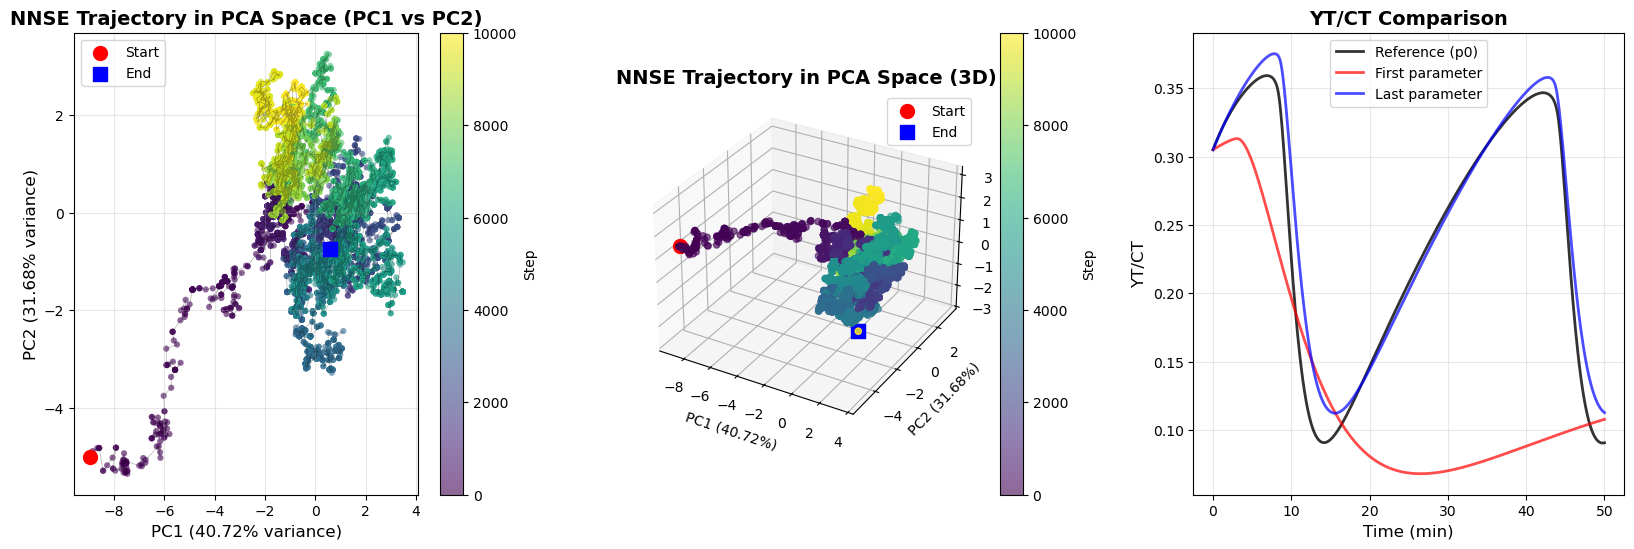

In [75]:
# ============================================================================
# === VISUALIZATION: PCA TRAJECTORY ===
# ============================================================================

print("Computing PCA for trajectory visualization...")

# Normalize trajectory for PCA (use standardized parameters)
trajectory_normalized = (trajectory - trajectory.mean(axis=0)) / (trajectory.std(axis=0) + 1e-10)

# Compute PCA
pca = PCA(n_components=min(3, n_params))
trajectory_pca = pca.fit_transform(trajectory_normalized)

print(f"✓ PCA complete")
print(f"  Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"  Total explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")

# Simulate with first and last parameters for YT/CT comparison
print("Simulating with first and last parameters...")
P_first = trajectory[0]
P_last = trajectory[-1]

# Convert to parameter dictionaries
p_first = copy.deepcopy(p0)
p_last = copy.deepcopy(p0)
for i, name in enumerate(param_names):
    p_first[name] = P_first[i]
    p_last[name] = P_last[i]

# Simulate
t_first, y_first = simulate_at_params(p_first, t_eval)
YT_first, M_first = compute_obs(y_first)
t_last, y_last = simulate_at_params(p_last, t_eval)
YT_last, M_last = compute_obs(y_last)

print("✓ Simulations complete")

# Create figure with 3 subplots
fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# Plot 2D PCA trajectory
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(trajectory_pca[:, 0], trajectory_pca[:, 1], 
                     c=range(len(trajectory_pca)), cmap='viridis', 
                     s=20, alpha=0.6, edgecolors='none')
ax1.plot(trajectory_pca[:, 0], trajectory_pca[:, 1], 'k-', alpha=0.3, linewidth=0.5)
ax1.scatter(trajectory_pca[0, 0], trajectory_pca[0, 1], 
           color='red', s=100, marker='o', label='Start', zorder=5)
ax1.scatter(trajectory_pca[-1, 0], trajectory_pca[-1, 1], 
           color='blue', s=100, marker='s', label='End', zorder=5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
ax1.set_title('NNSE Trajectory in PCA Space (PC1 vs PC2)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Step')

# Second subplot: 3D plot or squared difference over time
if trajectory_pca.shape[1] >= 3:
    from mpl_toolkits.mplot3d import Axes3D
    ax2 = fig.add_subplot(gs[0, 1], projection='3d')
    scatter2 = ax2.scatter(trajectory_pca[:, 0], trajectory_pca[:, 1], trajectory_pca[:, 2],
                         c=range(len(trajectory_pca)), cmap='viridis', s=20, alpha=0.6)
    ax2.plot(trajectory_pca[:, 0], trajectory_pca[:, 1], trajectory_pca[:, 2], 
            'k-', alpha=0.3, linewidth=0.5)
    ax2.scatter(trajectory_pca[0, 0], trajectory_pca[0, 1], trajectory_pca[0, 2],
               color='red', s=100, marker='o', label='Start')
    ax2.scatter(trajectory_pca[-1, 0], trajectory_pca[-1, 1], trajectory_pca[-1, 2],
               color='blue', s=100, marker='s', label='End')
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=10)
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=10)
    ax2.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})', fontsize=10)
    ax2.set_title('NNSE Trajectory in PCA Space (3D)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    plt.colorbar(scatter2, ax=ax2, label='Step')
else:
    # If only 2 components, show squared difference over time
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(range(len(squared_diffs)), squared_diffs, 'b-', linewidth=1, alpha=0.7)
    ax2.set_xlabel('Step', fontsize=12)
    ax2.set_ylabel('Squared Difference', fontsize=12)
    ax2.set_title('Squared Difference Over Time', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

# Third subplot: YT/CT comparison
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(t0, YT0, 'k-', lw=2, label='Reference (p0)', alpha=0.8)
ax3.plot(t_first, YT_first, 'r-', lw=2, label='First parameter', alpha=0.7)
ax3.plot(t_last, YT_last, 'b-', lw=2, label='Last parameter', alpha=0.7)
ax3.set_xlabel('Time (min)', fontsize=12)
ax3.set_ylabel('YT/CT', fontsize=12)
ax3.set_title('YT/CT Comparison', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Plotting distribution of squared differences...
  Valid values: 10001/10001
  Mean: 1.168938e-01
  Median: 8.396421e-02
  Min: 7.436430e-04
  Max: 4.763249e+00


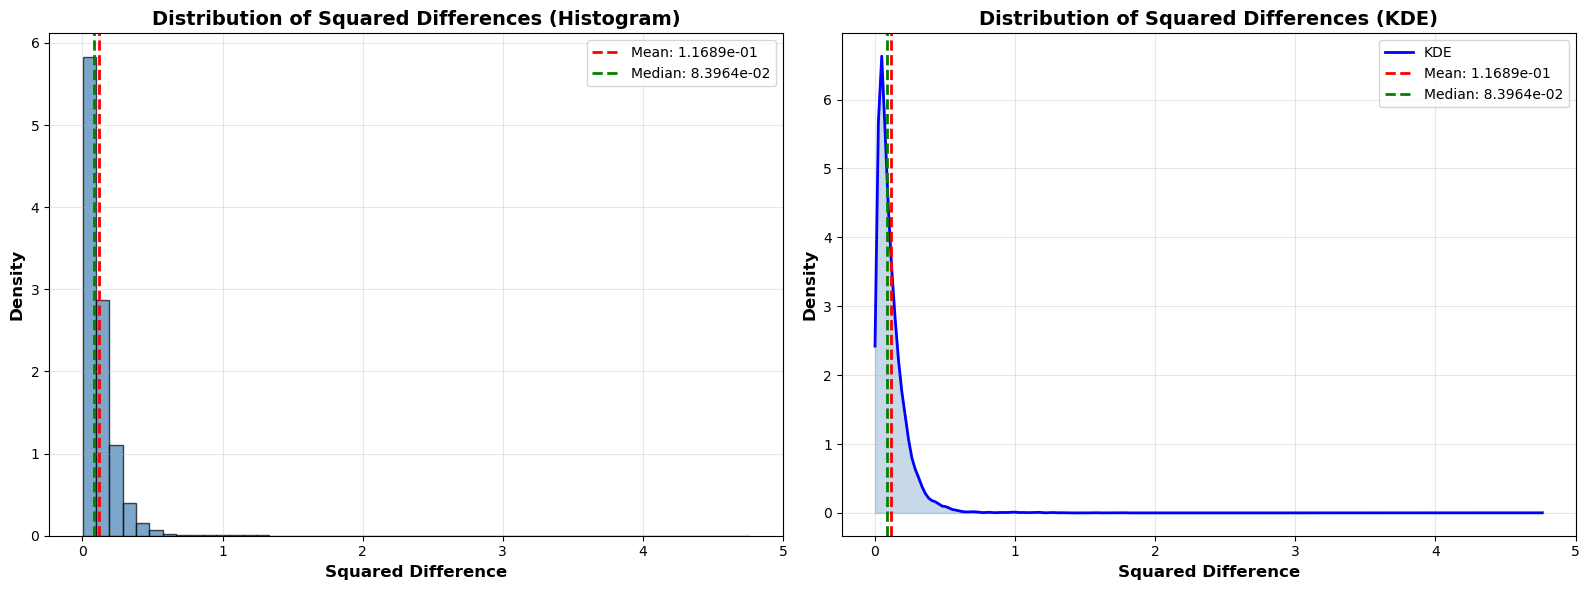

✓ Distribution plots complete


In [76]:
# ============================================================================
# === VISUALIZATION: DISTRIBUTION OF SQUARED DIFFERENCES ===
# ============================================================================
# This plots the distribution of squared differences (integrated squared error 
# compared to p0 reference) for all parameter points visited during the NNSE simulation.
# This shows how the squared differences are distributed across the parameter space.

print("Plotting distribution of squared differences...")

# Filter out infinite values
valid_mask = np.isfinite(squared_diffs)
squared_diffs_valid = squared_diffs[valid_mask]

print(f"  Valid values: {np.sum(valid_mask)}/{len(squared_diffs)}")
print(f"  Mean: {np.mean(squared_diffs_valid):.6e}")
print(f"  Median: {np.median(squared_diffs_valid):.6e}")
print(f"  Min: {np.min(squared_diffs_valid):.6e}")
print(f"  Max: {np.max(squared_diffs_valid):.6e}")

# Create distribution plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram with linear bins
ax1 = axes[0]
n_bins_hist = 50
# Use linear bins from min to max
counts, bins_hist, patches = ax1.hist(squared_diffs_valid, bins=n_bins_hist, 
                                      edgecolor='black', alpha=0.7, color='steelblue',
                                      density=True)
ax1.axvline(np.mean(squared_diffs_valid), color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {np.mean(squared_diffs_valid):.4e}')
ax1.axvline(np.median(squared_diffs_valid), color='green', linestyle='--', 
           linewidth=2, label=f'Median: {np.median(squared_diffs_valid):.4e}')
ax1.set_xlabel('Squared Difference', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Squared Differences (Histogram)', 
             fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Kernel density estimate (KDE) with linear scale
ax2 = axes[1]
from scipy.stats import gaussian_kde
if len(squared_diffs_valid) > 1:
    # Use linear KDE (not log-transformed)
    kde = gaussian_kde(squared_diffs_valid)
    x_kde = np.linspace(squared_diffs_valid.min(), squared_diffs_valid.max(), 200)
    density = kde(x_kde)
    ax2.plot(x_kde, density, 'b-', linewidth=2, label='KDE')
    ax2.fill_between(x_kde, 0, density, alpha=0.3, color='steelblue')
    ax2.axvline(np.mean(squared_diffs_valid), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.mean(squared_diffs_valid):.4e}')
    ax2.axvline(np.median(squared_diffs_valid), color='green', linestyle='--', 
               linewidth=2, label=f'Median: {np.median(squared_diffs_valid):.4e}')
    ax2.set_xlabel('Squared Difference', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax2.set_title('Distribution of Squared Differences (KDE)', 
                 fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Not enough data for KDE', 
            ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Distribution of Squared Differences (KDE)', 
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Distribution plots complete")


In [77]:
# ============================================================================
# === PARAMETER COMPARISON TABLE ===
# ============================================================================

# Get parameter vectors
P_init = trajectory[0]  # Initial parameter
P_final = trajectory[-1]  # Final parameter
P_ref = p0_vec  # Reference parameter (p0)

# Print table header
print(f"{'Parameter':<20} {'P_init':<15} {'P_final':<15} {'P_ref':<15}")
print("-" * 65)

# Print each parameter
for i, name in enumerate(param_names):
    print(f"{name:<20} {P_init[i]:<15.6e} {P_final[i]:<15.6e} {P_ref[i]:<15.6e}")


Parameter            P_init          P_final         P_ref          
-----------------------------------------------------------------
k1_aa_over_CT        3.495132e-03    1.431391e-02    1.500000e-02   
k3_CT                2.806749e+02    4.338861e+00    2.000000e+02   
k4                   1.540027e+02    1.911155e+02    1.800000e+02   
k4prime              1.705935e-02    1.510562e-02    1.800000e-02   
k6                   2.531600e-01    9.193369e-01    1.000000e+00   
k7                   1.738184e-01    4.478084e-01    6.000000e-01   
